[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Solving multi-class classification problems with softmax regression


## Multi-class classification

To get our feet wet, let's start with
a simple image classification problem.
Here, each input consists of a $2\times2$ grayscale image.
We can represent each pixel value with a feature that represents its pixel value,
giving us four features $x_1, x_2, x_3, x_4$.
Further, let's assume that each image belongs to one
of the categories "cat", "chicken", and "dog".

Next, we have to choose how to represent the labels.
We have two obvious choices.
Perhaps the most natural impulse would be
to choose $y \in \{1, 2, 3\}$,
where the integers represent
$\{\textrm{dog}, \textrm{cat}, \textrm{chicken}\}$ respectively.
This is a great way of *storing* such information on a computer.
If the categories had some natural ordering among them,
say if we were trying to predict
$\{\textrm{baby}, \textrm{toddler}, \textrm{adolescent}, \textrm{young adult}, \textrm{adult}, \textrm{geriatric}\}$.

However, in general, classification problems do not come
with natural orderings among the classes.
Fortunately, statisticians long ago invented a simple way
to represent categorical data: the **one-hot encoding**.
A one-hot encoding is a vector
with as many components as we have categories.
The component corresponding to a particular instance's category is set to 1
and all other components are set to 0.
In our case, a label $y$ would be a three-dimensional vector,
with $(1, 0, 0)$ corresponding to "cat", $(0, 1, 0)$ to "chicken",
and $(0, 0, 1)$ to "dog" i.e.

$$y \in \{(1, 0, 0), (0, 1, 0), (0, 0, 1)\}.$$


### Linear Model

In order to estimate the conditional probabilities
associated with all the possible classes,
we need a model with multiple outputs, one per class.
To address classification with linear models,
we will need as many affine functions as we have outputs.
Strictly speaking, we only need one fewer,
since the final category has to be the difference
between $1$ and the sum of the other categories,
but for reasons of symmetry
we use a slightly redundant parametrization.
Each output corresponds to its own affine function.
In our case, since we have 4 features and 3 possible output categories,
we need 12 scalars to represent the weights ($w$ with subscripts),
and 3 scalars to represent the biases ($b$ with subscripts). This yields:

$$
\begin{aligned}
o_1 &= x_1 w_{11} + x_2 w_{12} + x_3 w_{13} + x_4 w_{14} + b_1,\\
o_2 &= x_1 w_{21} + x_2 w_{22} + x_3 w_{23} + x_4 w_{24} + b_2,\\
o_3 &= x_1 w_{31} + x_2 w_{32} + x_3 w_{33} + x_4 w_{34} + b_3.
\end{aligned}
$$

Just as in linear regression,
we use a single-layer neural network.
And since the calculation of each output, $o_1, o_2$, and $o_3$,
depends on every input, $x_1$, $x_2$, $x_3$, and $x_4$,
the output layer can also be described as a *fully connected layer*.

In [ ]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import numpy as np
import matplotlib.pyplot as plt

def _fc_network(ax, in_labels, out_labels, x_in=0.0, x_out=2.6, r=0.30,
                dy=0.95, dy_out=None, in_fill='0.92', out_fill='#dce7f2',
                edge_color='0.62', edge_lw=0.7):
    """A fully connected layer: every input circle joined to every output."""
    from matplotlib.patches import Circle

    dy_out = dy if dy_out is None else dy_out
    n_in, n_out = len(in_labels), len(out_labels)
    y_in = [(n_in - 1) / 2 * dy - i * dy for i in range(n_in)]
    y_out = [(n_out - 1) / 2 * dy_out - i * dy_out for i in range(n_out)]

    for yi in y_in:
        for yo in y_out:
            ax.plot([x_in + r, x_out - r], [yi, yo], color=edge_color,
                    linewidth=edge_lw, zorder=1)
    for y, label in zip(y_in, in_labels):
        ax.add_patch(Circle((x_in, y), r, facecolor=in_fill, edgecolor='0.35',
                            linewidth=1.0, zorder=3))
        ax.text(x_in, y, label, ha='center', va='center', fontsize=8.5, zorder=4)
    for y, label in zip(y_out, out_labels):
        ax.add_patch(Circle((x_out, y), r, facecolor=out_fill, edgecolor='0.35',
                            linewidth=1.0, zorder=3))
        ax.text(x_out, y, label, ha='center', va='center', fontsize=8.5, zorder=4)
    return y_in, y_out

def _bias_node(ax, x_in, y, x_out, y_out, labels, r=0.30, fill='0.92',
               edge_color='0.62', edge_lw=0.7, t=0.78):
    """The bias as a constant input.

    One more node in the input layer, permanently equal to 1.  Its edges are
    ordinary edges, so the bias is just the weight on each of them — the same
    story the $w$'s tell.
    """
    from matplotlib.patches import Circle

    for yo, label in zip(y_out, labels):
        x0, x1 = x_in + r, x_out - r
        ax.plot([x0, x1], [y, yo], color=edge_color, linewidth=edge_lw,
                zorder=1)
        ax.text(x0 + t * (x1 - x0), y + t * (yo - y), label, ha='center',
                va='center', fontsize=8.5, color='0.25', zorder=5,
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor='none'))
    ax.add_patch(Circle((x_in, y), r, facecolor=fill, edgecolor='0.35',
                        linewidth=1.0, zorder=3))
    ax.text(x_in, y, '$1$', ha='center', va='center', fontsize=8.5, zorder=4)
    ax.text(x_in, y - r - 0.22, 'constant\ninput', ha='center', va='top',
            fontsize=7, color='0.45', linespacing=1.3)

def softmax_network_figure():
    """Softmax regression: four inputs fully connected to three outputs."""
    fig, ax = plt.subplots(figsize=(5.65, 5.39))
    x_in, x_out, r, dy = 0.0, 3.5, 0.24, 0.74
    y_in, y_out = _fc_network(ax, ['$x_1$', '$x_2$', '$x_3$', '$x_4$'],
                              ['$o_1$', '$o_2$', '$o_3$'], x_in, x_out, r, dy,
                              dy_out=1.00)

    # two representative weights: the first edge and the last
    for (yi, yo, label, side) in [(y_in[0], y_out[0], '$w_{11}$', 1),
                                  (y_in[3], y_out[2], '$w_{34}$', -1)]:
        x0, x1 = x_in + r, x_out - r
        t = 0.30
        xm, ym = x0 + t * (x1 - x0), yi + t * (yo - yi)
        dx, dy_ = x1 - x0, yo - yi
        n = np.hypot(dx, dy_)
        s = 0.15 * side
        ax.text(xm - s * dy_ / n, ym + s * dx / n, label, ha='center',
                va='center', fontsize=8.5, color='0.25', zorder=5,
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor='none'))

    y_bias = min(y_in) - dy
    _bias_node(ax, x_in, y_bias, x_out, y_out, ['$b_1$', '$b_2$', '$b_3$'], r=r)

    top = max(y_in) + r
    ax.text(x_in, top + 0.52, 'input layer', ha='center', va='center',
            fontsize=9, fontweight='bold', color='0.3')
    ax.text(x_out, top + 0.52, 'output layer', ha='center', va='center',
            fontsize=9, fontweight='bold', color='0.3')
    ax.text(x_in, top + 0.22, '4 features $+$ constant', ha='center',
            va='center', fontsize=7.6, color='0.45')
    ax.text(x_out, top + 0.22, '3 classes', ha='center', va='center',
            fontsize=7.6, color='0.45')

    for y, name in zip(y_out, ['cat', 'chicken', 'dog']):
        ax.text(x_out + r + 0.14, y, name, ha='left', va='center',
                fontsize=8, color='0.4')

    ax.text((x_in + x_out) / 2, y_bias - r - 0.85,
            r'the biases $b_i$ are the weights on the edges out of the constant input',
            ha='center', va='center', fontsize=8, color='0.4')

    ax.set_xlim(x_in - 0.85, x_out + 1.30)
    ax.set_ylim(y_bias - r - 1.15, top + 0.80)
    ax.set_aspect('equal')
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

softmax_network_figure()

For a more concise notation we use vectors and matrices:

$$\mathbf{o} = \mathbf{W} \mathbf{x} + \mathbf{b}$$

This representation is
much better suited for mathematics and code.
Note that we have gathered all of our weights into a $3 \times 4$ matrix and all biases
$\mathbf{b} \in \mathbb{R}^3$ in a vector.

### The Softmax

Assuming a suitable loss function,
we could try to directly minimize the difference
between the output $\mathbf{o}$ and the labels $\mathbf{y}$.
While it turns out that treating classification
as a vector-valued regression problem works surprisingly well,
it is nonetheless unsatisfactory in the following ways:

* There is no guarantee that the outputs $o_i$ sum up to $1$ in the way we expect probabilities to behave.
* There is no guarantee that the outputs $o_i$ are even nonnegative, even if their outputs sum up to $1$, or that they do not exceed $1$.

Both aspects render the estimation problem difficult to solve
and the solution very brittle to outliers.
For instance, if we assume that there
is a positive linear dependency
between the number of bedrooms and the likelihood
that someone will buy a house,
the probability might exceed $1$
when it comes to buying a mansion!
As such, we need a mechanism to "squish" the outputs.

We will achieve this similarly to how we did it in the case of logistic regression.
To accomplish this goal
(and to ensure nonnegativity) we will use
an exponential function and estimate 
$$P(y = i) \propto \exp o_i.$$

This does indeed satisfy the requirement
that the conditional class probability
increases with increasing $o_i$,
and all outputs are nonnegative.
We can then transform these values so that they add up to $1$
by dividing each by their sum.
This process is called *normalization*.
Putting these two pieces together
gives us the **softmax** function:

$$\hat{\mathbf{y}} = \mathrm{softmax}(\mathbf{o}) \quad \textrm{where}\quad \hat{y}_i = \frac{\exp(o_i)}{\sum_j \exp(o_j)}.$$

Note that the largest coordinate of $\mathbf{o}$
corresponds to the most likely class according to $\hat{\mathbf{y}}$.
Moreover, because the softmax operation
preserves the ordering among its arguments,
we do not need to compute the softmax
to determine which class has been assigned the highest probability. Thus,

$$
\operatorname*{argmax}_j \hat y_j = \operatorname*{argmax}_j o_j.
$$


The idea of the softmax dates back to Boltzmann,
the father of modern statistical physics,
who used this trick to model a distribution
over energy states in gas molecules.
In particular, he discovered that the prevalence
of a state of energy in a thermodynamic ensemble,
such as the molecules in a gas,
is proportional to $\exp(-E/kT)$.
Here, $E$ is the energy of a state,
$T$ is the temperature, and $k$ is the Boltzmann constant.
When statisticians talk about increasing or decreasing
the "temperature" of a statistical system,
they refer to changing $T$
in order to favor lower or higher energy states.


### Visualizing the effect of the softmax function

Here is a simple bit of code to help you visualize what happens when the activations on the last layer of a classification network are run through the softmax function:

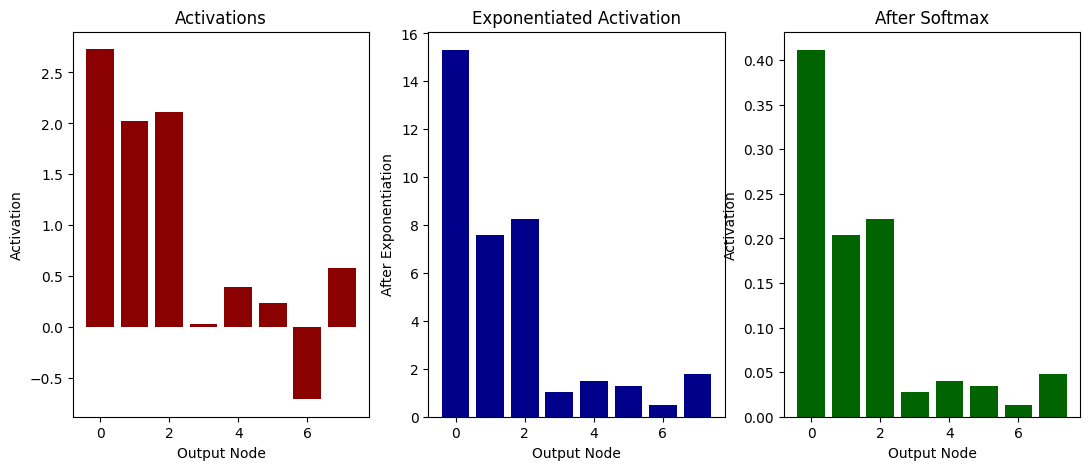

In [1]:
import numpy as np
from matplotlib import pyplot as plt

def apply_softmax(acts) :
    exp_acts = np.array([np.exp(x) for x in acts])
    exp_acts_sum = np.sum(exp_acts)
    acts_smax = np.array([np.exp(x)/exp_acts_sum for x in acts])
    return exp_acts, acts_smax

def visualize_softmax(mean, sigma, nsamples, rseed) :
    rng = np.random.default_rng(rseed)
    act = rng.normal(mean, sigma, nsamples)
    aex, asf = apply_softmax(act)
    #plt.style.use('seaborn-deep')
    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(13,5))
    ax1.bar(range(nsamples), act, color='darkred')
    ax1.set_xlabel('Output Node')
    ax1.set_ylabel('Activation')
    ax1.set_title('Activations')   
    ax2.bar(range(nsamples), aex, color='darkblue')
    ax2.set_xlabel('Output Node')
    ax2.set_ylabel('After Exponentiation')
    ax2.set_title('Exponentiated Activation')  
    ax3.bar(range(nsamples), asf, color='darkgreen')
    ax3.set_xlabel('Output Node')
    ax3.set_ylabel('Activation')
    ax3.set_title('After Softmax')
visualize_softmax(1, 1.0, 8, 82)    

### Vectorized calculation of network output

To improve computational efficiency, we vectorize calculations in minibatches of data.
Assume that we are given a minibatch $\mathbf{X} \in \mathbb{R}^{n \times d}$
of $n$ examples with dimensionality (number of inputs) $d$.
Moreover, assume that we have $q$ categories in the output.
Then the weights are a matrix $\mathbf{W} \in \mathbb{R}^{d \times q}$
and the bias is a vector $\mathbf{b} \in \mathbb{R}^{q}$.

$$ \begin{aligned} \mathbf{O} &= \mathbf{X} \mathbf{W} + \mathbf{b}, \\ \hat{\mathbf{Y}} & = \mathrm{softmax}(\mathbf{O}). \end{aligned} $$

This accelerates the dominant operation by representing it as
a matrix--matrix product $\mathbf{X} \mathbf{W}$.
Moreover, since each row in $\mathbf{X}$ represents a data example,
the softmax operation itself can be computed *rowwise*:
for each row of $\mathbf{O}$, exponentiate all entries
and then normalize them by the sum.
Note, though, that care must be taken
to avoid exponentiating and taking logarithms of large numbers,
since this can cause numerical overflow or underflow.
Deep learning frameworks take care of this automatically.


## The Loss Function

Now that we have a mapping from features $\mathbf{x}$
to probabilities $\mathbf{\hat{y}}$,
we need a way to optimize the accuracy of this mapping.
Again, we will rely on the principle of maximum likelihood estimation, as we have done before.

### The Log-Likelihood Solution

The softmax function gives us a vector $\hat{\mathbf{y}}$,
which we can interpret as the (estimated) conditional probabilities
of each class, given any input $\mathbf{x}$,
such as $\hat{y}_1$ = $P(y=\textrm{cat} \mid \mathbf{x})$.
In the following we assume that for a dataset
with features $\mathbf{X}$ the labels $\mathbf{Y}$
are represented using a one-hot encoding label vector.
We can compare the estimates with reality
by checking how probable the actual classes are
according to our model, given the features:

$$
P(\mathbf{Y} \mid \mathbf{X}) = \prod_{i=1}^n P(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)}).
$$

We are allowed to use the factorization
since we assume that each label is drawn independently
from its respective distribution $P(\mathbf{y}\mid\mathbf{x}^{(i)})$.
Since maximizing the product of terms is awkward,
we take the negative logarithm to obtain the equivalent problem
of minimizing the negative log-likelihood:

$$
-\log P(\mathbf{Y} \mid \mathbf{X}) = \sum_{i=1}^n -\log P(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)})
= \sum_{i=1}^n l(\mathbf{y}^{(i)}, \hat{\mathbf{y}}^{(i)}),
$$

where for any pair of label $\mathbf{y}$
and model prediction $\hat{\mathbf{y}}$
over $q$ classes, the loss function $l$ is

$$ l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{j=1}^q y_j \log \hat{y}_j. $$

For reasons explained later on,
this loss function 
is commonly called the **cross-entropy loss**.
Since $\mathbf{y}$ is a one-hot vector of length $q$,
the sum over all its coordinates $j$ vanishes for all but one term.
Note that the loss $l(\mathbf{y}, \hat{\mathbf{y}})$
is bounded from below by $0$
whenever $\hat{\mathbf{y}}$ is a probability vector:
no single entry is larger than $1$,
hence their negative logarithm cannot be lower than $0$;
$l(\mathbf{y}, \hat{\mathbf{y}}) = 0$ only if we predict
the actual label with *certainty*.
This can never happen for any finite setting of the weights
because taking a softmax output towards $1$
requires taking the corresponding input $o_i$ to infinity
(or all other outputs $o_j$ for $j \neq i$ to negative infinity).
Even if our model could assign an output probability of $0$,
any error made when assigning such high confidence
would incur infinite loss ($-\log 0 = \infty$).



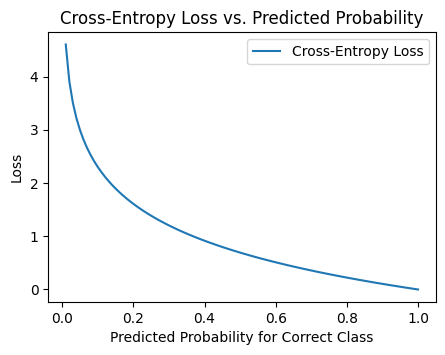

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# true label: class 2 (one-hot encoded)
y_true = np.array([0, 1, 0])

# predicted probabilities for the correct class (y_pred[1])
pred_probs = np.linspace(0.01, 1, 100)  # Avoid 0 to prevent log(0)

# cross-entropy loss for each predicted probability
losses = -np.log(pred_probs)

plt.figure(figsize=(5,3.5))
plt.plot(pred_probs, losses, label="Cross-Entropy Loss")
plt.xlabel("Predicted Probability for Correct Class")
plt.ylabel("Loss")
plt.title("Cross-Entropy Loss vs. Predicted Probability")
plt.legend();

### Observations

Here are a couple of observations that can help you understand cross-entropy as a loss function:

* **Cross-entropy focuses on the correct class**: Cross-entropy only considers the probability assigned to the correct class.
* Cross-entropy loss penalizes incorrect predictions more heavily when the model is confident in the wrong class.


### The Softmax and Cross-Entropy Loss

Since the softmax function
and the corresponding cross-entropy loss are so common,
it is worth understanding a bit better how they are computed.
Plugging the definition of the softmax function into the definition of the cross-entropy loss we obtain:

$$
\begin{aligned}
l(\mathbf{y}, \hat{\mathbf{y}}) &=  - \sum_{j=1}^q y_j \log \frac{\exp(o_j)}{\sum_{k=1}^q \exp(o_k)} \\
&= \sum_{j=1}^q y_j \log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j \\
&= \log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j.
\end{aligned}
$$

To understand a bit better what is going on,
consider the derivative with respect to any logit $o_j$. We get

$$
\partial_{o_j} l(\mathbf{y}, \hat{\mathbf{y}}) = \frac{\exp(o_j)}{\sum_{k=1}^q \exp(o_k)} - y_j = \mathrm{softmax}(\mathbf{o})_j - y_j.
$$

In other words, the derivative is the difference
between the probability assigned by our model,
as expressed by the softmax operation,
and what actually happened, as expressed
by elements in the one-hot label vector.
In this sense, it is very similar
to what we saw in regression,
where the gradient was the difference
between the observation $y$ and estimate $\hat{y}$.
This is not a coincidence.
In any exponential family model,
the gradients of the log-likelihood are given by precisely this term.
This fact makes computing gradients easy in practice.

We can demystify the name of the loss function - the cross entropy - by introducing a few of the basics of information theory.
In a nutshell, it measures the number of bits needed to encode what we see, $\mathbf{y}$,
relative to what we predict that should happen, $\hat{\mathbf{y}}$.


## Information Theory Basics

Many deep learning papers use intuition and terms from information theory.
To make sense of them, we need some common language.
This is a survival guide.  *Information theory* deals with the problem
of encoding, decoding, transmitting,
and manipulating information (also known as data).

### Entropy

The central idea in information theory is to quantify the
amount of information contained in data.
This places a  limit on our ability to compress data.
For a distribution $P$ its *entropy*, $H[P]$, is defined as:

$$H[P] = - \sum_j P(j) \log_2 P(j).$$

One of the fundamental theorems of information theory states
that in order to encode data drawn randomly from the distribution $P$,
we need at least $H[P]$ **bits** to encode it.
By using the base-2 logarithm we measure information in bits, the natural unit
for the yes/no questions we will use below: one bit is exactly the information
carried by a single yes/no answer when both outcomes are equally likely.


#### Building intuition: a number-guessing game

Here is a concrete way to feel what entropy measures. I am thinking of an integer
between $0$ and $1023$, and you must find it by asking yes/no questions. How many
questions do you need?

If every number is equally likely, the best strategy is **binary search**: each
question ("Is your number greater than the midpoint?") splits the remaining
candidates exactly in half, so each answer carries the maximum possible information —
exactly **one bit**. Since $1024 = 2^{10}$, you can always pin down the number in
$10$ questions, and the sequence of yes/no answers *is* the binary representation of
the number. This is no accident: the entropy of a uniform distribution over $1024$
outcomes is

$$H[P] = -\sum_{j=0}^{1023}\frac{1}{1024}\log_2\frac{1}{1024} = \log_2 1024 = 10 \text{ bits}.$$

Entropy is the average number of yes/no questions an optimal strategy needs. Let's
watch binary search elicit the bits one at a time.

In [3]:
import numpy as np

def guess_number(secret, lo=0, hi=1023, verbose=True):
    """Binary search for `secret` in [lo, hi]; each question yields one bit."""
    bits = []
    step = 0
    while lo < hi:
        mid = (lo + hi) // 2
        step += 1
        answer = secret > mid          # the yes/no answer
        bit = int(answer)
        bits.append(bit)
        if verbose:
            print(f"Q{step:2d}: Is it > {mid:4d}?  "
                  f"{'yes' if answer else 'no ':>3}  ->  bit = {bit}   "
                  f"(range now [{(mid+1) if answer else lo}, {hi if answer else mid}])")
        if answer:
            lo = mid + 1
        else:
            hi = mid
    return lo, bits

secret = 742
found, bits = guess_number(secret)
print()
print(f"Found {found} in {len(bits)} questions.")
print(f"Answer bits : {''.join(map(str, bits))}")
print(f"742 in binary: {secret:010b}   <- identical!")


Q 1: Is it >  511?  yes  ->  bit = 1   (range now [512, 1023])
Q 2: Is it >  767?  no   ->  bit = 0   (range now [512, 767])
Q 3: Is it >  639?  yes  ->  bit = 1   (range now [640, 767])
Q 4: Is it >  703?  yes  ->  bit = 1   (range now [704, 767])
Q 5: Is it >  735?  yes  ->  bit = 1   (range now [736, 767])
Q 6: Is it >  751?  no   ->  bit = 0   (range now [736, 751])
Q 7: Is it >  743?  no   ->  bit = 0   (range now [736, 743])
Q 8: Is it >  739?  yes  ->  bit = 1   (range now [740, 743])
Q 9: Is it >  741?  yes  ->  bit = 1   (range now [742, 743])
Q10: Is it >  742?  no   ->  bit = 0   (range now [742, 742])

Found 742 in 10 questions.
Answer bits : 1011100110
742 in binary: 1011100110   <- identical!


### Surprisal

You might be wondering what compression has to do with prediction.
Imagine that we have a stream of data that we want to compress.
If it is always easy for us to predict the next token,
then this data is easy to compress.
Take the extreme example where every token in the stream
always takes the same value.
That is a very boring data stream!
And not only it is boring, but it is also easy to predict.
Because the tokens are always the same,
we do not have to transmit any information
to communicate the contents of the stream.
Easy to predict, easy to compress.

However if we cannot perfectly predict every event,
then we might sometimes be surprised.
Our surprise is greater when an event is assigned lower probability.
Claude Shannon settled on $\log_2 \frac{1}{P(j)} = -\log_2 P(j)$
to quantify one's *surprisal* (in bits) at observing an event $j$
having assigned it a (subjective) probability $P(j)$.
The entropy defined above
is then the *expected surprisal*
when one assigned the correct probabilities
that truly match the data-generating process.


#### Predictable data has low entropy

The guessing game assumed every number was equally likely — the hardest case. Real
data streams are usually skewed: some outcomes are far more common than others, and
those are *easier to predict* and therefore *easier to compress*. Entropy captures
this. The more peaked a distribution, the lower its entropy (less average surprisal);
the flatter it is, the higher its entropy, up to the uniform maximum of $\log_2 q$
for $q$ outcomes.

In [4]:
def entropy(p, base=2):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]                      # 0 * log 0 = 0 by convention
    return -np.sum(p * np.log(p)) / np.log(base)

distributions = {
    "uniform   [.25 .25 .25 .25]": [0.25, 0.25, 0.25, 0.25],
    "mild skew [.40 .30 .20 .10]": [0.40, 0.30, 0.20, 0.10],
    "peaked    [.97 .01 .01 .01]": [0.97, 0.01, 0.01, 0.01],
}

for name, dist in distributions.items():
    print(f"{name}   H = {entropy(dist):.3f} bits")

print(f"\nMaximum possible over 4 outcomes: log2(4) = {np.log2(4):.1f} bits")
print("The uniform distribution is the most surprising / least compressible;")
print("the peaked one is nearly certain, so it carries little information.")


uniform   [.25 .25 .25 .25]   H = 2.000 bits
mild skew [.40 .30 .20 .10]   H = 1.846 bits
peaked    [.97 .01 .01 .01]   H = 0.242 bits

Maximum possible over 4 outcomes: log2(4) = 2.0 bits
The uniform distribution is the most surprising / least compressible;
the peaked one is nearly certain, so it carries little information.


### Cross-Entropy

So if entropy is the level of surprise experienced
by someone who knows the true probability,
then you might be wondering, what is cross-entropy?
The cross-entropy *from* $P$ *to* $Q$, denoted $H(P, Q)$,
is the expected surprisal of an observer with subjective probabilities $Q$
upon seeing data that was actually generated according to probabilities $P$.
This is given by 
$$H(P, Q) \stackrel{\textrm{def}}{=} - \sum_j P(j) \log_2 Q(j).$$
The lowest possible cross-entropy is achieved when $P=Q$.
In this case, the cross-entropy from $P$ to $Q$ is $H(P, P)= H(P)$.

In short, we can think of the cross-entropy classification objective
in two ways: (i) as maximizing the likelihood of the observed data;
and (ii) as minimizing our surprisal (and thus the number of bits)
required to communicate the labels.

Cross entropy can also be thought of as a "distance" between two probability distributions.  So we can think of our optimization as trying to minimize the discrepancy between the true distribution $P$ and the model, represented by $Q$.

A note on units: throughout this section we use the base-2 logarithm, so entropy, surprisal, and cross-entropy are all measured in **bits**. The cross-entropy *loss* we minimize when training uses the natural logarithm (nats) instead. The two differ only by the constant factor $1/\ln 2$, so they are equivalent for optimization: the parameters that minimize the loss in nats are exactly the same as those that minimize it in bits.


#### Cross-entropy in code: the cost of a wrong model

Cross-entropy $H(P, Q)$ is the average surprisal you experience when the data truly
follows $P$ but you encode it using your model $Q$. If your model is perfect ($Q=P$)
you pay only the unavoidable entropy $H(P)$. Any mismatch costs *extra* bits — and
that excess is exactly the quantity our training minimizes. The gap
$H(P,Q) - H(P)$ is the Kullback–Leibler divergence, a non-negative "distance" from
$P$ to $Q$ that is zero only when the two distributions agree.

In [5]:
def cross_entropy(p, q, base=2):
    p, q = np.asarray(p, float), np.asarray(q, float)
    mask = p > 0
    return -np.sum(p[mask] * np.log(q[mask])) / np.log(base)

P = np.array([0.7, 0.2, 0.1])      # true distribution

models = {
    "Q = P        (perfect)  ": P,
    "Q close to P            ": np.array([0.6, 0.25, 0.15]),
    "Q far from P            ": np.array([0.1, 0.2, 0.7]),
}

HP = entropy(P)
print(f"True entropy           H(P)   = {HP:.3f} bits\n")
for name, Q in models.items():
    HPQ = cross_entropy(P, Q)
    print(f"{name}  H(P,Q) = {HPQ:.3f} bits   "
          f"extra (KL) = {HPQ - HP:.3f}")

print("\nH(P,Q) >= H(P) always, with equality only when Q = P.")
print("Training a classifier drives Q toward P, shrinking the extra bits to zero.")


True entropy           H(P)   = 1.157 bits

Q = P        (perfect)    H(P,Q) = 1.157 bits   extra (KL) = 0.000
Q close to P              H(P,Q) = 1.190 bits   extra (KL) = 0.033
Q far from P              H(P,Q) = 2.841 bits   extra (KL) = 1.684

H(P,Q) >= H(P) always, with equality only when Q = P.
Training a classifier drives Q toward P, shrinking the extra bits to zero.


## Summary and Discussion

In this section, we encountered the first nontrivial loss function,
allowing us to optimize over *discrete* output spaces.
Key in its design was that we took a probabilistic approach,
treating discrete categories as instances of draws from a probability distribution.
As a side effect, we encountered the softmax, an activation function that transforms outputs of an ordinary neural network layer into valid discrete probability distributions.
We saw that the derivative of the cross-entropy loss when combined with the softmax function is leads to similar behavior to the derivative of squared error:  namely by taking the difference between the expected behavior and its prediction.
And, while we were only able to scratch the very surface, we encountered exciting connections to statistical physics and information theory.

## A note on the softmax function

The softmax gets its name from the following mapping: 
$$\textrm{RealSoftMax}(a, b) = \log (\exp(a) + \exp(b))$$
This function is a smooth version of the function $\mathrm{max}(a, b)$. To see that, consider that $\lambda \to \infty$ we have $\lambda^{-1} \textrm{RealSoftMax}(\lambda a, \lambda b) \to \mathrm{max}(a, b)$.